In [ ]:
# ==============================================================
# Imports and setup
# ==============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==============================================================
# Model definition (same as before)
# ==============================================================
class MLPStepper(nn.Module):
    def __init__(self, in_dim=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, u_left, u_center, u_right, dt_norm):
        inp = torch.stack([u_left, u_center, u_right, dt_norm], dim=-1)
        du = self.net(inp).squeeze(-1)
        return u_center + du

# ==============================================================
# Load the trained model weights
# ==============================================================
model = MLPStepper(in_dim=4, hidden=128).to(device)
model.load_state_dict(torch.load("variable_dt_model.pth", map_location=device))
model.eval()
print("✅ Loaded trained variable-Δt model")

# ==============================================================
# Rollout helper (for future RL or manual tests)
# ==============================================================
def rollout_model(model, u0, dt_sequence, steps=None):
    u_test = torch.tensor(u0, dtype=torch.float32, device=device)
    rollout = [u_test.cpu().numpy()]
    if steps is None:
        steps = len(dt_sequence)
    for i in range(steps):
        dt_mult = dt_sequence[i]
        u_left  = torch.roll(u_test, +1)
        u_right = torch.roll(u_test, -1)
        dt_norm = torch.full_like(u_test, float(dt_mult))
        u_test = model(u_left, u_test, u_right, dt_norm).detach()
        rollout.append(u_test.cpu().numpy())
    return np.stack(rollout)


Using device: cpu
✅ Loaded trained variable-Δt model


In [5]:
# ==============================================================
# Simple RL environment wrapper for the diffusion NN
# ==============================================================

class DiffusionEnv:
    def __init__(self, model, u0, true_data, dt0, max_mult=4):
        self.model = model
        self.u = torch.tensor(u0, dtype=torch.float32, device=device)
        self.true = true_data
        self.dt0 = dt0
        self.max_mult = max_mult
        self.t_step = 0
        self.done = False

    def reset(self):
        self.u = torch.tensor(u0, dtype=torch.float32, device=device)
        self.t_step = 0
        self.done = False
        return self.u

    def step(self, action):
        """Action = Δt multiplier ∈ [1, max_mult]"""
        dt_mult = int(action)
        u_left  = torch.roll(self.u, +1)
        u_right = torch.roll(self.u, -1)
        dt_norm = torch.full_like(self.u, float(dt_mult))
        u_pred = self.model(u_left, self.u, u_right, dt_norm).detach()

        # compute reward (negative error + penalty for large Δt)
        true_next = torch.tensor(self.true[self.t_step + dt_mult],
                                 dtype=torch.float32, device=device)
        mse = ((u_pred - true_next) ** 2).mean()
        reward = -mse.item() - 0.01 * dt_mult

        self.u = u_pred
        self.t_step += dt_mult
        if self.t_step >= len(self.true) - self.max_mult:
            self.done = True

        return self.u, reward, self.done


In [10]:
# -----------------------
# 1. Diffusion solver
# -----------------------
def diffusion_solver(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=500):
    """Explicit finite-difference diffusion solver (periodic BCs)."""
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_steps):
        lap = (np.roll(u,-1) - 2*u + np.roll(u,1)) / dx**2
        u = u + nu * dt * lap
        traj.append(u.copy())
    return np.stack(traj)


In [12]:
# ==============================================================
# Policy network (agent) – outputs discrete Δt choice
# ==============================================================

class PolicyNet(nn.Module):
    def __init__(self, nx=128, hidden=64, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nx, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, u):
        # flatten spatial dimension
        x = u.view(1, -1)
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)


In [20]:
# ==============================================================
# Simple RL training loop
# ==============================================================

policy = PolicyNet(nx=128, hidden=64, n_actions=4).to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

n_episodes = 200
gamma = 0.99   # discount factor

# -----------------------
# Define spatial grid and initial condition
# -----------------------
Nx = 128
dx = 1 / Nx
dt0 = 1e-4
nu = 0.01
n_steps = 500

x = np.linspace(0, 1, Nx, endpoint=False)
u0 = np.sin(2 * np.pi * x)
data = diffusion_solver(u0, nu, dx, dt0, n_steps)
u = torch.tensor(data, dtype=torch.float32)

# clear any old dt_sequence
if 'dt_sequence' in locals():
    del dt_sequence

# -----------------------
# RL training loop
# -----------------------
for ep in range(n_episodes):
    env = DiffusionEnv(model, u0, data, dt0)
    u = env.reset()
    log_probs, rewards = [], []

    while not env.done:
        # policy selects Δt multiplier (1–4)
        probs = policy(u)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))

        # step environment with chosen Δt
        u, r, done = env.step(action.item() + 1)
        rewards.append(r)

        chosen_dt = action.item() + 1
        print(f"Step {env.t_step:4d}, Δt={chosen_dt}, reward={r:.4f}")

        # record dt sequence for last episode
        if ep == n_episodes - 1:
            if 'dt_sequence' not in locals():
                dt_sequence = []
            dt_sequence.append(chosen_dt)

    # -----------------------
    # Policy update (REINFORCE)
    # -----------------------
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32, device=device)

    loss = -torch.stack([lp * G for lp, G in zip(log_probs, returns)]).sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Episode {ep+1}/{n_episodes}, total reward = {sum(rewards):.4f}")


Step    4, Δt=4, reward=-0.0400
Step    8, Δt=4, reward=-0.0400
Step   10, Δt=2, reward=-0.0200
Step   12, Δt=2, reward=-0.0200
Step   13, Δt=1, reward=-0.0100
Step   17, Δt=4, reward=-0.0400
Step   21, Δt=4, reward=-0.0400
Step   25, Δt=4, reward=-0.0400
Step   27, Δt=2, reward=-0.0200
Step   31, Δt=4, reward=-0.0400
Step   34, Δt=3, reward=-0.0300
Step   37, Δt=3, reward=-0.0300
Step   38, Δt=1, reward=-0.0100
Step   42, Δt=4, reward=-0.0400
Step   43, Δt=1, reward=-0.0100
Step   47, Δt=4, reward=-0.0400
Step   48, Δt=1, reward=-0.0100
Step   51, Δt=3, reward=-0.0300
Step   55, Δt=4, reward=-0.0400
Step   56, Δt=1, reward=-0.0100
Step   60, Δt=4, reward=-0.0400
Step   64, Δt=4, reward=-0.0400
Step   68, Δt=4, reward=-0.0400
Step   72, Δt=4, reward=-0.0400
Step   73, Δt=1, reward=-0.0100
Step   74, Δt=1, reward=-0.0100
Step   75, Δt=1, reward=-0.0100
Step   77, Δt=2, reward=-0.0200
Step   80, Δt=3, reward=-0.0300
Step   82, Δt=2, reward=-0.0200
Step   83, Δt=1, reward=-0.0100
Step   8

In [19]:
print(dt_sequence)

NameError: name 'dt_sequence' is not defined

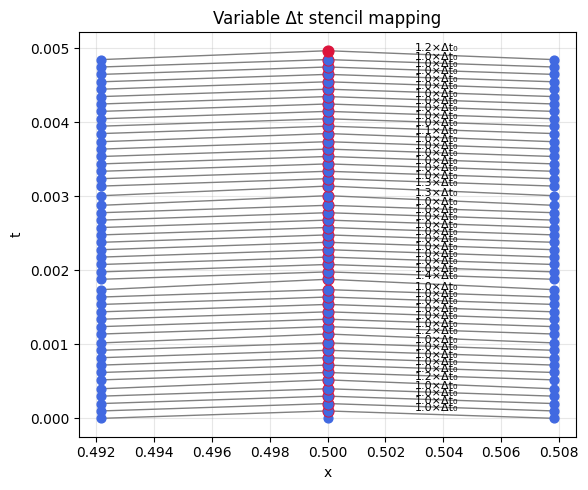

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dt_stencil(dt_sequence, x_c=0.5, dx=1/128, dt0=1e-4):
    """
    Visualize variable Δt steps and stencils in (x, t) space.
    """
    # cumulative time levels
    t_levels = np.cumsum([0] + [m * dt0 for m in dt_sequence])

    plt.figure(figsize=(6,5))
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Variable Δt stencil mapping")

    for n, mult in enumerate(dt_sequence):
        t_c = t_levels[n]
        t_next = t_levels[n+1]

        # spatial neighbors
        x_inputs = [x_c - dx, x_c, x_c + dx]
        t_inputs = [t_c, t_c, t_c]

        # next target
        x_target = [x_c]
        t_target = [t_next]

        # draw gray connections
        for xi, ti in zip(x_inputs, t_inputs):
            plt.plot([xi, x_target[0]], [ti, t_target[0]], color='gray', lw=1)

        # draw input and output nodes
        plt.scatter(x_inputs, t_inputs, color='royalblue', s=40, zorder=3)
        plt.scatter(x_target, t_target, color='crimson', s=60, zorder=3)

        # label each level
        plt.text(x_c+0.003, t_next, f"{mult}×Δt₀", color='black', fontsize=8)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
def average_sequence(seq, group_size=100):
    seq = np.array(seq, dtype=float)
    n = len(seq)
    # truncate to a multiple of group_size
    n_groups = n // group_size
    seq = seq[:n_groups * group_size]
    return seq.reshape(n_groups, group_size).mean(axis=1)

# Average every 5 Δt values
dt_sequence_avg = average_sequence(dt_sequence, group_size=10)

plot_dt_stencil(dt_sequence_avg)





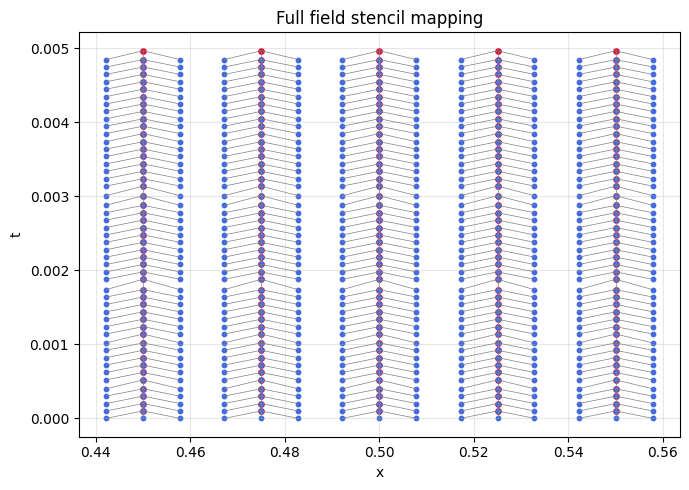

In [27]:
def plot_dt_stencil_full(dt_sequence, x_centers, dx=1/128, dt0=1e-4):
    t_levels = np.cumsum([0] + [m * dt0 for m in dt_sequence])
    plt.figure(figsize=(7,5))
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Full field stencil mapping")

    for x_c in x_centers:
        for n, mult in enumerate(dt_sequence):
            t_c, t_next = t_levels[n], t_levels[n+1]
            x_inputs = [x_c - dx, x_c, x_c + dx]
            t_inputs = [t_c, t_c, t_c]
            x_target, t_target = [x_c], [t_next]
            for xi, ti in zip(x_inputs, t_inputs):
                plt.plot([xi, x_target[0]], [ti, t_target[0]], color='gray', lw=0.5)
            plt.scatter(x_inputs, t_inputs, color='royalblue', s=10)
            plt.scatter(x_target, t_target, color='crimson', s=15)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example use (show several spatial positions)
x_centers = np.linspace(0.45, 0.55, 5)
plot_dt_stencil_full(dt_sequence_avg, x_centers)
